# *Iris* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/53/iris)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

The [*Iris* dataset](https://archive.ics.uci.edu/dataset/53/iris) is the main example dataset used in part I of the course.

This dataset contains physical measurements of iris flowers, as the predictive attributes, accompanied by the indication of the species each specimen belongs to, as the class.

In particular, from the [dataset description](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names) we can find the list of attributes:


| Name | Unit |
| ---- | ---- |
| sepal length | cm |
| sepal width  | cm |
| petal length | cm |
| petal width  | cm |
| **class** | 'Iris-setosa', 'Iris-versicolor' or 'Iris-virginica' |


The classification task typically considered is to predict the species of a flower specimen based on its physical measurements.

We load the data from the `iris.data` file. This file does not contain names for the columns, so we provide them as the `names` input parameter to the `read_csv` function.

In [2]:
iris_path = "./iris/iris.data"
cnames = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth", "Class"]
iris_dtf = pandas.read_csv(iris_path, sep=",", names=cnames)

The iris species, recorded in column `Class`, is the classification target. We obtain the counts of specimens of each species, i.e. we tally the occurrences of each value in the `Class` column.

In [3]:
iris_targetname = "Class"
iris_dtf.value_counts(iris_targetname)

Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

We see that the dataset contains three different classes, corresponding each to an iris species, and that the classes are perfectly balanced, with exactly fifty samples each.

We show descriptive statistics. The `Class` variable, containing strings, is automatically excluded by default.

Since all four predictive attributes are numerical,  for each of them the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

Recall that the *x*th percentile is the threshold such that *x* percent of values fall below it. In particular, the 50th percentile is the threshold such that fifty percent of values fall below it, and hence half of values are above. It is also known as the *median*.

In [4]:
iris_dtf.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Sepals and petals are on average clearly longer than they are wide, with sepals on average larger than petals.

We show an outline of the dataset, displaying the first and last few rows.

In [5]:
iris_dtf

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Finally, we visualize the dataset with *seaborn*'s `pairplot` function.

It generates a scatter plot of each of the four predictive attributes against each other predictive attribute, where each dot represents an iris specimen, arranged into a grid. The plots along the diagonal of the grid represent the distribution of the values for the corresponding attribute considered separately. The three iris species are depicted with the same three colors as in the course material.

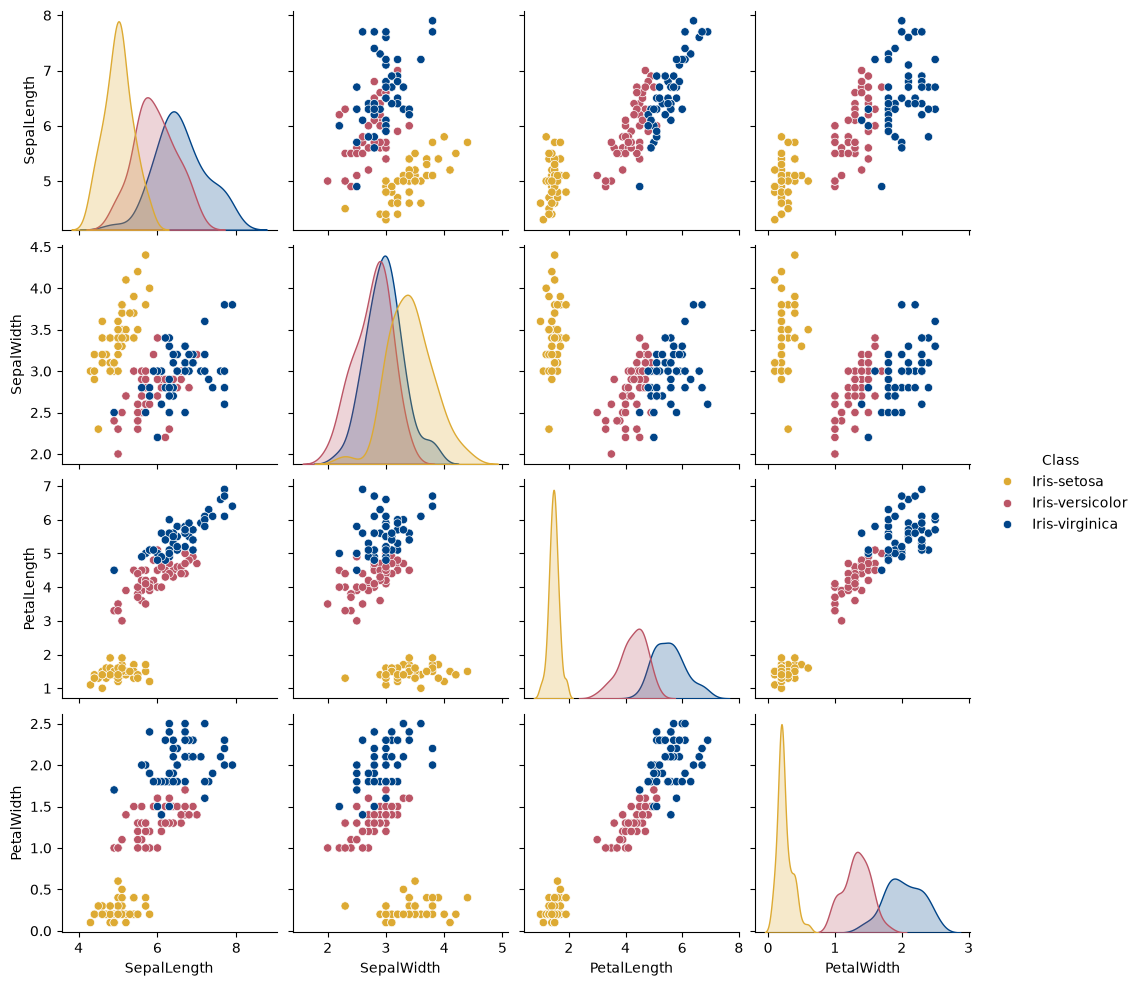

In [6]:
# Create an array with the colors for the different species
species_to_colors = {"Iris-setosa":"#DDAA33", "Iris-versicolor": "#BB5566", "Iris-virginica": "#004488"}
species = sorted(pandas.unique(iris_dtf[iris_targetname]))
iris_palette = seaborn.color_palette([species_to_colors[s] for s in species])

seaborn.pairplot(iris_dtf, hue=iris_targetname, hue_order=species, palette=iris_palette);

In all scatter plots, the clouds of yellow points, representing specimens of *Iris setosa*, are always clearly separated, whereas the clouds of red and blue points, representing respectively specimens of *Iris versicolor* and of *Iris viginica*, show some overlap for all pairs of dimensions and especially in the *sepal length* vs. *sepal width* plot.

The density plots along the diagonal show that *Iris setosa*, in yellow, are typically smaller on all dimensions, except sepal width, where they are on average slightly larger than the other two species. Furthermore, when compared to the other species, the dimensions of the petals of *Iris setosa* specimens do not vary much, with both curves showing a large peak.

Considering the task of classifying iris specimens in this dataset based on their physical measurements, it seems that *Iris setosa* specimens should be relatively easy to identify, while *Iris versicolor* and *Iris viginica* specimens might be more difficult to tell apart, since they have more similar sizes.